# Dominos Stock Prediction - LSTM



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from sklearn.preprocessing import MinMaxScaler

In [2]:
dataset=pd.read_csv("Dominos_Stock_Data.csv")
display(dataset)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-10-16,254.89,257.61,253.08,255.96,251.60,525200
1,2019-10-17,256.12,259.96,255.78,256.45,252.09,515100
2,2019-10-18,257.45,258.40,254.23,255.70,251.35,609900
3,2019-10-21,256.61,259.84,255.67,257.52,253.14,499600
4,2019-10-22,257.27,259.47,255.38,258.94,254.53,343100
...,...,...,...,...,...,...,...
500,2021-10-11,477.88,484.46,472.43,479.48,479.48,359600
501,2021-10-12,481.37,483.16,476.13,480.05,480.05,413500
502,2021-10-13,479.72,480.46,474.03,476.28,476.28,629700
503,2021-10-14,461.00,489.89,455.96,477.48,477.48,1518300


In [3]:
dataset['Date']=pd.to_datetime(dataset['Date'])
dataset=dataset.sort_values('Date',ascending=True).reset_index(drop=True)
#dataset['Date']=dataset['Date'].astype(str)
display(dataset)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-10-16,254.89,257.61,253.08,255.96,251.60,525200
1,2019-10-17,256.12,259.96,255.78,256.45,252.09,515100
2,2019-10-18,257.45,258.40,254.23,255.70,251.35,609900
3,2019-10-21,256.61,259.84,255.67,257.52,253.14,499600
4,2019-10-22,257.27,259.47,255.38,258.94,254.53,343100
...,...,...,...,...,...,...,...
500,2021-10-11,477.88,484.46,472.43,479.48,479.48,359600
501,2021-10-12,481.37,483.16,476.13,480.05,480.05,413500
502,2021-10-13,479.72,480.46,474.03,476.28,476.28,629700
503,2021-10-14,461.00,489.89,455.96,477.48,477.48,1518300


In [4]:
trainset=dataset.iloc[-1000:-100,1:2].values #Open
testset=dataset.iloc[-100:,1:2].values #Open 
real_stock_price = testset.copy()

In [5]:
sc = MinMaxScaler(feature_range = (0,1))
training_scaled = sc.fit_transform(trainset)
print(training_scaled[0:5])
print(len(training_scaled))

[[0.        ]
 [0.00679145]
 [0.01413506]
 [0.00949699]
 [0.01314118]]
405


In [6]:
x_train = []
y_train = []

In [7]:
for i in range(60,len(training_scaled)):
    x_train.append(training_scaled[i-60:i, 0])
    y_train.append(training_scaled[i,0])
x_train,y_train = np.array(x_train),np.array(y_train)
print(x_train.shape,y_train.shape)

(345, 60) (345,)


In [8]:
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))
print('(samples, time steps, features) =',x_train.shape)

(samples, time steps, features) = (345, 60, 1)


In [9]:
regressor = Sequential()
regressor.add(LSTM(units = 50,return_sequences = True,input_shape = (x_train.shape[1],1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units = 1))

In [10]:
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')
regressor.fit(x_train,y_train,epochs =10, batch_size = 32)

Epoch 1/10
11/11 [==============================] - 2s 34ms/step - loss: 0.1397
Epoch 2/10
11/11 [==============================] - 0s 36ms/step - loss: 0.0284
Epoch 3/10
11/11 [==============================] - 0s 33ms/step - loss: 0.0215
Epoch 4/10
11/11 [==============================] - 0s 33ms/step - loss: 0.0182
Epoch 5/10
11/11 [==============================] - 0s 33ms/step - loss: 0.0171
Epoch 6/10
11/11 [==============================] - 0s 31ms/step - loss: 0.0166
Epoch 7/10
11/11 [==============================] - 0s 30ms/step - loss: 0.0177
Epoch 8/10
11/11 [==============================] - 0s 31ms/step - loss: 0.0167
Epoch 9/10
11/11 [==============================] - 0s 33ms/step - loss: 0.0156
Epoch 10/10
11/11 [==============================] - 0s 33ms/step - loss: 0.0164


In [11]:
inputs = dataset.iloc[len(trainset)-len(testset)-60:,1].values
print(inputs.shape)
print(inputs[0:10])

(260,)
[426.55 429.8  405.9  403.   392.   393.62 408.41 402.61 401.72 400.73]


In the context of a LSTM model, this reshaping may be necessary if the input data has only one feature (i.e., one time series) and the LSTM model expects a 3D input shape of (n_samples, n_time_steps, n_features). In this case, since there is only one feature, the shape does not change.

In [12]:
inputs = inputs.reshape(-1,1)
print(inputs.shape)

#sc = MinMaxScaler(feature_range = (0,1))
inputs = sc.transform(inputs)
print(inputs.shape)

(260, 1)
(260, 1)


In [13]:
x_test = []
for i in range(60,len(inputs)):
    x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
print(x_test.shape)

x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
print(x_test.shape)

(200, 60)
(200, 60, 1)


In [14]:
predicted_price = regressor.predict(x_test)

7/7 [==============================] - 1s 8ms/step


In [15]:
predicted_price = sc.inverse_transform(predicted_price)
print(predicted_price.shape)

(200, 1)


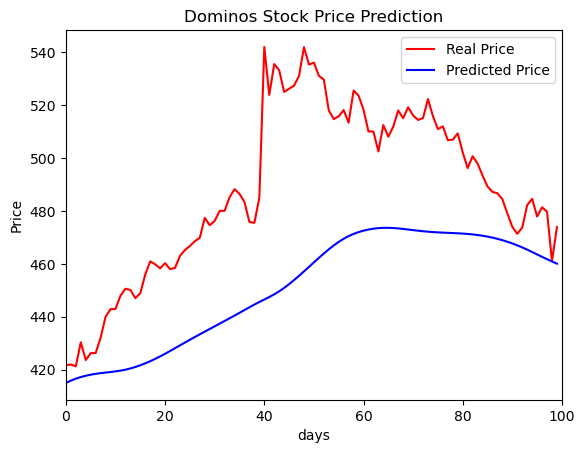

In [25]:
plt.plot(real_stock_price[-100:],color = 'red', label = 'Real Price')
plt.plot(predicted_price[-100:], color = 'blue', label = 'Predicted Price')
plt.title('Dominos Stock Price Prediction')
plt.xlabel('days')
plt.ylabel('Price')
plt.xlim(0,100)  
plt.legend()
plt.show()

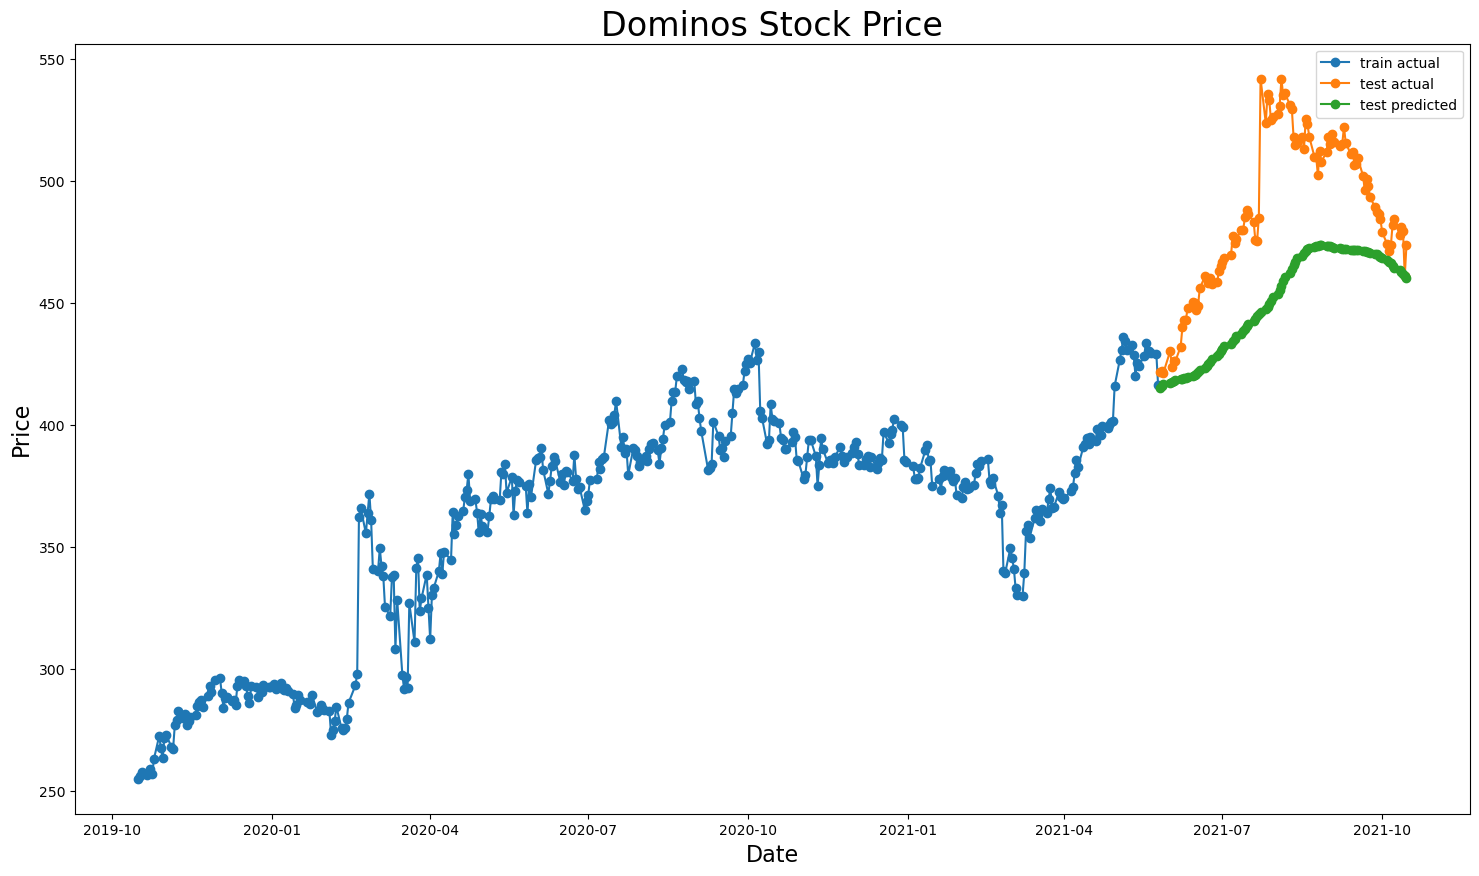

In [24]:
plt.figure(figsize=(18,10))
plt.plot(dataset.iloc[-1000:-100,0],trainset,'-o',label='train actual')
#plt.plot(dataset.iloc[-1000:-100,0],train_pred,'--',label='Prophet')
plt.plot(dataset.iloc[-100:,0],real_stock_price[-100:],'-o',label='test actual')
plt.plot(dataset.iloc[-100:,0],predicted_price[-100:],'-o',label='test predicted')
plt.title('Dominos Stock Price',size=24)
plt.xlabel('Date',size=16)
plt.ylabel('Price',size=16)
plt.legend()
plt.show()

In [18]:
inputs = np.array(trainset[-60:])
new_predicted_price=[]
for i in range(100):
    x = np.reshape(inputs, (1,60,1))
    pred = regressor.predict(x)
    inputs = np.append(inputs, pred)
    inputs = inputs[1:]
    new_predicted_price+=[pred.reshape(-1)]

1/1 [==============================] - 0s 10ms/step


In [19]:
new_predicted_price = sc.inverse_transform(np.array(new_predicted_price))
print(new_predicted_price.shape)

(100, 1)


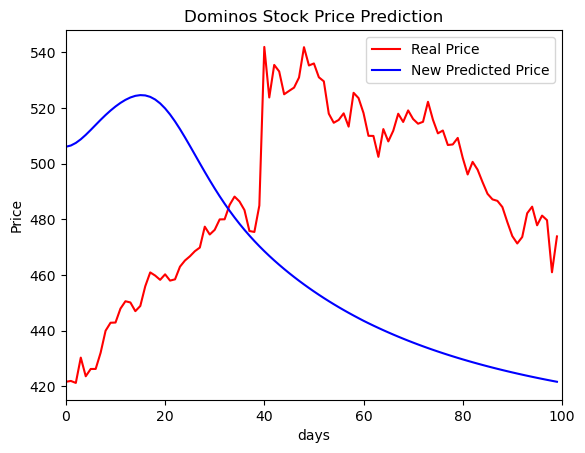

In [23]:
plt.plot(real_stock_price,color = 'red', label = 'Real Price')
plt.plot(new_predicted_price, color = 'blue', label = 'New Predicted Price')
plt.title('Dominos Stock Price Prediction')
plt.xlabel('days')
plt.ylabel('Price')
plt.xlim(0,100)  
plt.legend()
plt.show()

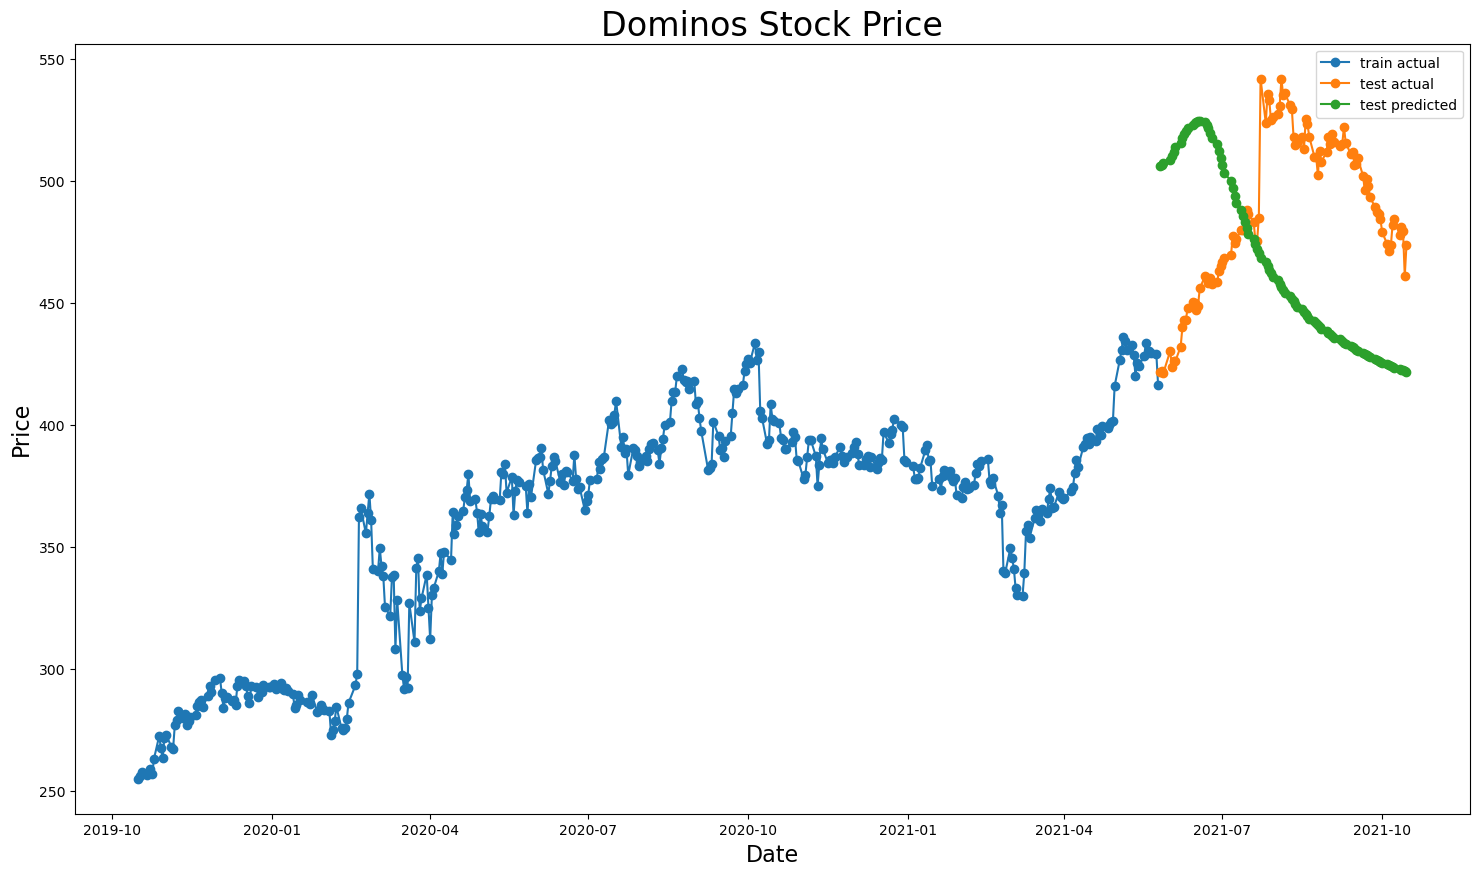

In [22]:
plt.figure(figsize=(18,10))
plt.plot(dataset.iloc[-1000:-100,0],trainset,'-o',label='train actual')
#plt.plot(dataset.iloc[-1000:-100,0],train_pred,'--',label='Prophet')
plt.plot(dataset.iloc[-100:,0],real_stock_price[-100:],'-o',label='test actual')
plt.plot(dataset.iloc[-100:,0],new_predicted_price[-100:],'-o',label='test predicted')
plt.title('Dominos Stock Price',size=24)
plt.xlabel('Date',size=16)
plt.ylabel('Price',size=16)
plt.legend()
plt.show()